In [1]:
!pip install torchview graphviz torchinfo --quiet

import os
import time
import math
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as models

from torchinfo import summary

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IMG_SIZE = 224
BATCH_SIZE = 6
NUM_WORKERS = 4
RANDOM_STATE = 42

CLASSES = ["No DR","Mild","Moderate","Severe","Proliferative DR"]
NUM_CLASSES = len(CLASSES)

In [2]:
TRAIN_CSV = "/kaggle/input/aptos2019-blindness-detection/train.csv"
TEST_CSV  = "/kaggle/input/aptos2019-blindness-detection/test.csv"

TRAIN_DIR = "/kaggle/input/aptos2019-blindness-detection/train_images"
TEST_DIR  = "/kaggle/input/aptos2019-blindness-detection/test_images"

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

# Add image paths
train_df["image_path"] = train_df["id_code"].apply(
    lambda x: os.path.join(TRAIN_DIR, x + ".png")
)

# APTOS test has NO labels → ignore for now
df_all = train_df[["image_path", "diagnosis"]].rename(columns={"diagnosis": "label"})

In [3]:
train_df, temp_df = train_test_split(
    df_all,
    test_size=0.2,
    stratify=df_all["label"],
    random_state=RANDOM_STATE
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=RANDOM_STATE
)

In [4]:
def print_split_stats(train_df, val_df, test_df, classes):

    print("\n===== DATASET SPLIT SUMMARY =====\n")

    print(f"Train size: {len(train_df)}")
    print(f"Validation size: {len(val_df)}")
    print(f"Test size: {len(test_df)}\n")

    def class_counts(df):
        return df['label'].value_counts().sort_index()

    train_counts = class_counts(train_df)
    val_counts = class_counts(val_df)
    test_counts = class_counts(test_df)

    print(f"{'Class':<20}{'Train':>10}{'Val':>10}{'Test':>10}")
    print("-"*55)

    for i, cls in enumerate(classes):
        print(f"{cls:<20}{train_counts.get(i,0):>10}{val_counts.get(i,0):>10}{test_counts.get(i,0):>10}")

print_split_stats(train_df, val_df, test_df, CLASSES)


===== DATASET SPLIT SUMMARY =====

Train size: 2929
Validation size: 366
Test size: 367

Class                    Train       Val      Test
-------------------------------------------------------
No DR                     1444       180       181
Mild                       296        37        37
Moderate                   799       100       100
Severe                     154        20        19
Proliferative DR           236        29        30


In [5]:
from PIL import Image as PILImage

class APTOSDataset(Dataset):

    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        img_path = self.df.loc[idx, 'image_path']
        label = self.df.loc[idx, 'label']

        image = PILImage.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [6]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

train_loader = DataLoader(
    APTOSDataset(train_df, transform),
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    APTOSDataset(val_df, transform),
    batch_size=BATCH_SIZE
)

test_loader = DataLoader(
    APTOSDataset(test_df, transform),
    batch_size=BATCH_SIZE
)

In [8]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, dim, num_heads=4):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5

        self.qkv = nn.Linear(dim, dim * 3)
        self.fc = nn.Linear(dim, dim)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        q, k, v = qkv.permute(2, 0, 3, 1, 4)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)

        out = (attn @ v).transpose(1, 2).reshape(B, N, C)
        return self.fc(out)

In [9]:
class TransformerBlock(nn.Module):
    def __init__(self, dim=32, num_heads=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = MultiHeadSelfAttention(dim, num_heads)
        self.norm2 = nn.LayerNorm(dim)

        self.mlp = nn.Sequential(
            nn.Linear(dim, 32),
            nn.GELU(),
            nn.Linear(32, dim)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

In [10]:
class TransformerBlock(nn.Module):
    def __init__(self, dim=32, num_heads=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = MultiHeadSelfAttention(dim, num_heads)
        self.norm2 = nn.LayerNorm(dim)

        self.mlp = nn.Sequential(
            nn.Linear(dim, 32),
            nn.GELU(),
            nn.Linear(32, dim)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

In [13]:
class CNN_ViT_Branch(nn.Module):
    def __init__(self):
        super().__init__()

        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)

        self.conv1 = nn.Conv2d(112, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)

        self.conv2 = nn.Conv2d(64, 16, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(16)

        self.patch_embed = nn.Conv2d(16, 32, kernel_size=7, stride=7)

        self.transformer = nn.Sequential(
            TransformerBlock(32, 4),
            TransformerBlock(32, 4)
        )

        self.pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):

        x = self.upsample(x)

        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))

        x = self.patch_embed(x)

        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)

        x = self.transformer(x)

        x = x.transpose(1, 2)
        x = self.pool(x).squeeze(-1)

        return x

In [14]:
from torchvision.models import EfficientNet_B0_Weights

class HybridEffNetViT(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        effnet = models.efficientnet_b0(
            weights=EfficientNet_B0_Weights.DEFAULT
        )

        self.features = effnet.features
        self.mid_layer = 5

        self.vit_branch = CNN_ViT_Branch()
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Linear(1280 + 32, num_classes)

    def forward(self, x):

        for i, layer in enumerate(self.features):
            x = layer(x)

            if i == self.mid_layer:
                mid_feature = x

        cnn_feat = self.gap(x).flatten(1)
        vit_feat = self.vit_branch(mid_feature)

        fused = torch.cat([cnn_feat, vit_feat], dim=1)

        return self.classifier(fused)

In [15]:
model = HybridEffNetViT(NUM_CLASSES).to(DEVICE)

summary(model, (1,3,224,224))

Layer (type:depth-idx)                                  Output Shape              Param #
HybridEffNetViT                                         [1, 5]                    --
├─Sequential: 1-1                                       --                        --
│    └─Conv2dNormActivation: 2-1                        [1, 32, 112, 112]         --
│    │    └─Conv2d: 3-1                                 [1, 32, 112, 112]         864
│    │    └─BatchNorm2d: 3-2                            [1, 32, 112, 112]         64
│    │    └─SiLU: 3-3                                   [1, 32, 112, 112]         --
│    └─Sequential: 2-2                                  [1, 16, 112, 112]         --
│    │    └─MBConv: 3-4                                 [1, 16, 112, 112]         1,448
│    └─Sequential: 2-3                                  [1, 24, 56, 56]           --
│    │    └─MBConv: 3-5                                 [1, 24, 56, 56]           6,004
│    │    └─MBConv: 3-6                              

In [19]:
num_epochs= 30

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

#  Adaptive LR Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.75,   # reduce LR by 25%
    patience=3
)

# Start LR scheduling AFTER epoch 10
lr_start_epoch = 10

best_val_loss = float("inf")

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [23]:
def custom_metrics(y_pred, y_true, loss):

    y_pred_classes = torch.argmax(y_pred, dim=1)

    y_true_np = y_true.cpu().numpy()
    y_pred_np = y_pred_classes.cpu().numpy()

    accuracy = accuracy_score(y_true_np, y_pred_np)
    precision = precision_score(y_true_np, y_pred_np, average='weighted', zero_division=0)
    recall = recall_score(y_true_np, y_pred_np, average='weighted', zero_division=0)
    f1 = f1_score(y_true_np, y_pred_np, average='weighted', zero_division=0)

    auc_scores = []
    for i in range(y_pred.shape[1]):
        binary_true = (y_true_np == i).astype(int)
        binary_pred = y_pred[:, i].cpu().numpy()

        if len(np.unique(binary_true)) > 1:
            auc_scores.append(roc_auc_score(binary_true, binary_pred))

    auc = np.mean(auc_scores) if auc_scores else 0

    return {
        "loss": loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "auc": auc
    }

In [25]:
metric_names = ["loss","accuracy","precision","recall","f1_score","auc"]

train_history = {m: [] for m in metric_names}
val_history = {m: [] for m in metric_names}

best_val_loss = float("inf")

for epoch in range(num_epochs):

    # ================= TRAIN =================
    model.train()
    total_train_loss = 0.0
    train_preds = []
    train_targets = []

    for data, targets in tqdm(train_loader, desc=f"Training Epoch [{epoch+1}/{num_epochs}]"):

        data = data.to(DEVICE)
        targets = targets.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, targets)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        train_preds.extend(outputs.detach().cpu().numpy())
        train_targets.extend(targets.detach().cpu().numpy())

    avg_train_loss = total_train_loss / len(train_loader)

    train_metrics = custom_metrics(
        torch.tensor(np.array(train_preds)),
        torch.tensor(np.array(train_targets)),
        avg_train_loss
    )

    print("Train Metrics - " + ", ".join([f"{k}: {v:.4f}" for k,v in train_metrics.items()]))

    for m in metric_names:
        train_history[m].append(train_metrics[m])


    # ================= VALIDATION =================
    model.eval()
    total_val_loss = 0.0
    val_preds = []
    val_targets = []

    with torch.no_grad():
        for data, targets in tqdm(val_loader, desc="Validating Model"):

            data = data.to(DEVICE)
            targets = targets.to(DEVICE)

            outputs = model(data)
            loss = criterion(outputs, targets)

            total_val_loss += loss.item()
            val_preds.extend(outputs.cpu().numpy())
            val_targets.extend(targets.cpu().numpy())

    avg_val_loss = total_val_loss / len(val_loader)

    val_metrics = custom_metrics(
        torch.tensor(np.array(val_preds)),
        torch.tensor(np.array(val_targets)),
        avg_val_loss
    )

    print("Val Metrics - " + ", ".join([f"{k}: {v:.4f}" for k,v in val_metrics.items()]))

    for m in metric_names:
        val_history[m].append(val_metrics[m])


    # ================= SAVE BEST MODEL =================
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "/kaggle/working/best_model.pth")
        print("✅ Best model saved")


    # ================= LR SCHEDULER =================
    if epoch + 1 >= lr_start_epoch:
        scheduler.step(avg_val_loss)

Training Epoch [1/30]: 100%|██████████| 489/489 [06:00<00:00,  1.36it/s]


Train Metrics - loss: 0.5504, accuracy: 0.7931, precision: 0.7786, recall: 0.7931, f1_score: 0.7787, auc: 0.9017


Validating Model: 100%|██████████| 61/61 [00:40<00:00,  1.49it/s]


Val Metrics - loss: 0.6825, accuracy: 0.7787, precision: 0.7809, recall: 0.7787, f1_score: 0.7641, auc: 0.8882
✅ Best model saved


Training Epoch [2/30]: 100%|██████████| 489/489 [05:52<00:00,  1.39it/s]


...

Val Metrics - loss: 1.0093, accuracy: 0.7787, precision: 0.7818, recall: 0.7787, f1_score: 0.7784, auc: 0.8803


Training Epoch [30/30]: 100%|██████████| 489/489 [06:18<00:00,  1.29it/s]


Train Metrics - loss: 0.0297, accuracy: 0.9863, precision: 0.9863, recall: 0.9863, f1_score: 0.9863, auc: 0.9981


Validating Model: 100%|██████████| 61/61 [00:43<00:00,  1.40it/s]

Val Metrics - loss: 1.0721, accuracy: 0.7978, precision: 0.7900, recall: 0.7978, f1_score: 0.7916, auc: 0.8736


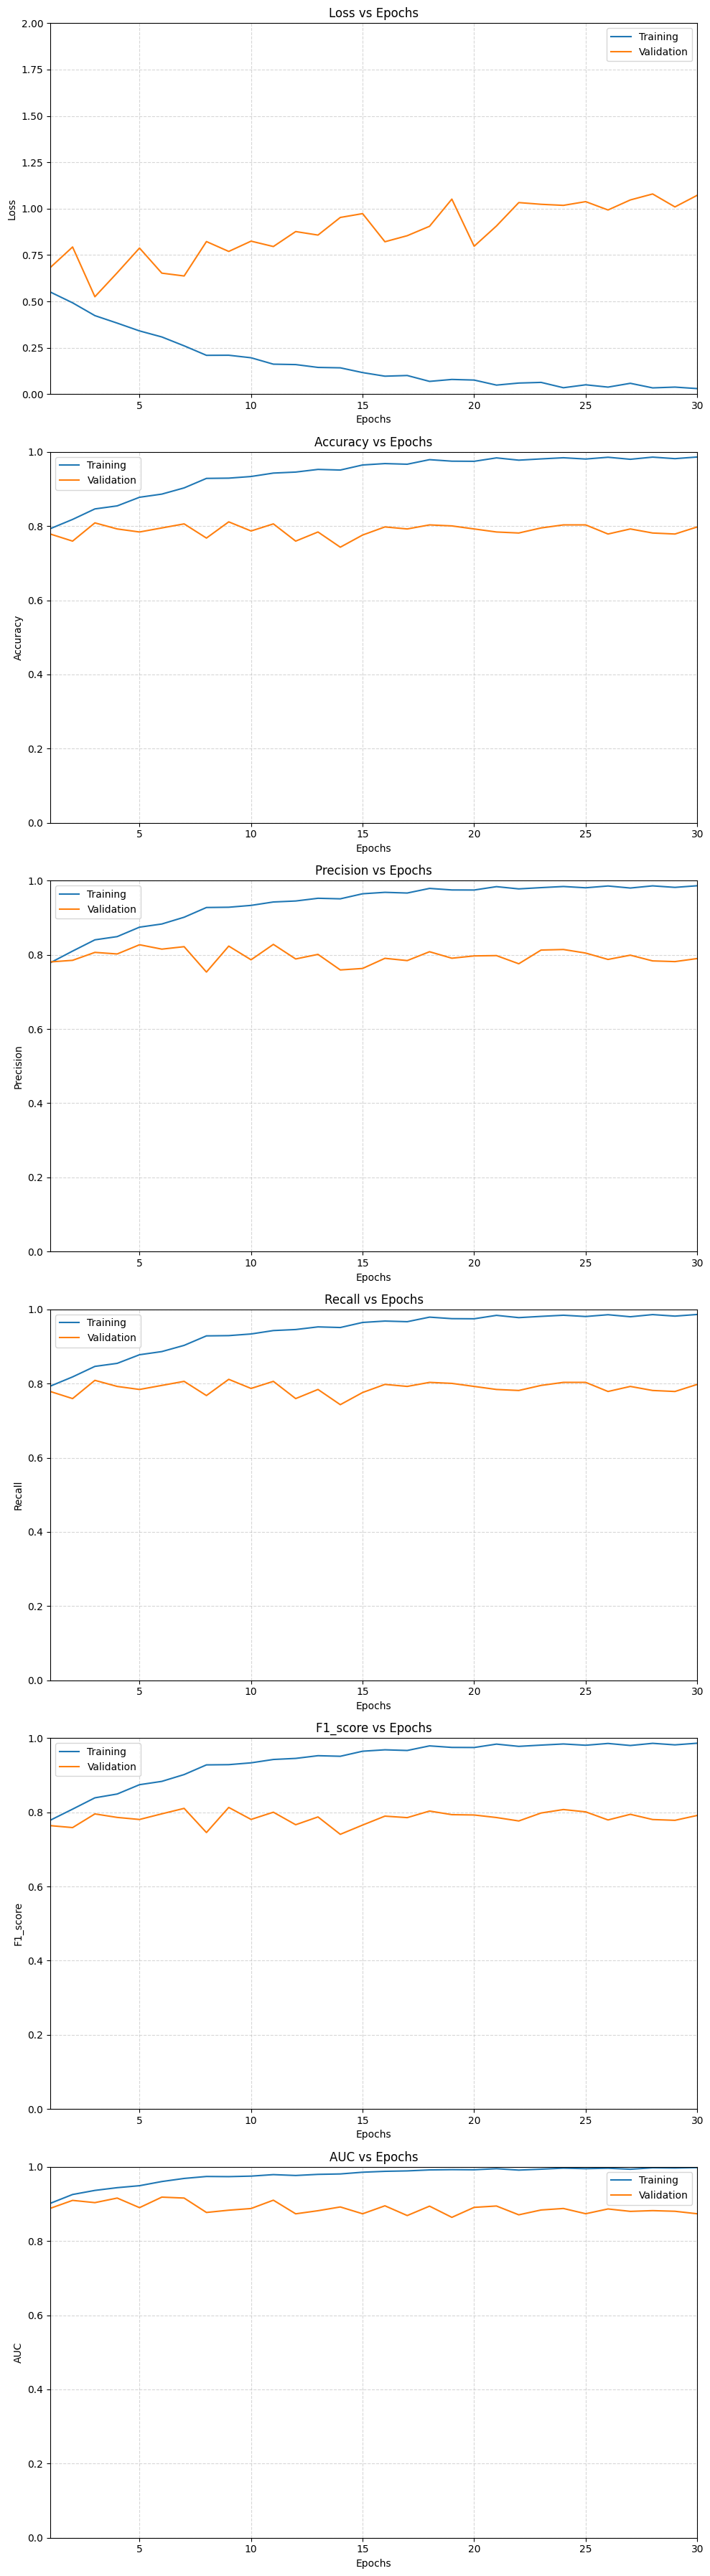

In [26]:
import math

def plot_metrics(train_metrics, val_metrics, metric_names):
    num_metrics = len(metric_names)
    num_epochs = len(train_metrics[metric_names[0]])

    figure, axes = plt.subplots(num_metrics, figsize=(10, 6 * num_metrics))
    if num_metrics == 1:
        axes = [axes]

    rng = range(1, num_epochs + 1)

    for ax, metric_name in zip(axes, metric_names):
        train_metric = train_metrics[metric_name]
        val_metric = val_metrics[metric_name]

        ax.plot(rng, train_metric, label="Training")
        ax.plot(rng, val_metric, label="Validation")
        ax.legend()
        ax.set_xlabel("Epochs")

        if metric_name == "auc":
            ax.set_ylabel("AUC")
            ax.set_title("AUC vs Epochs")
        else:
            ax.set_ylabel(metric_name.capitalize())
            ax.set_title(f"{metric_name.capitalize()} vs Epochs")

        max_metric = max(max(train_metric), max(val_metric))
        min_metric = min(min(train_metric), min(val_metric))
        y_max = math.ceil(max_metric)

        if min_metric > 0 or max_metric > 1:
            ax.set_ylim(0, y_max)
        else:
            ax.set_ylim(min_metric, y_max)

        ax.grid(True, linestyle='--', alpha=0.5)

        if num_epochs == 1:
            ax.set_xlim(0.5, 1.5)
        else:
            ax.set_xlim(1, num_epochs)

    plt.tight_layout()
    plt.show()


# ⭐ CORRECT CALL
plot_metrics(train_history, val_history, metric_names)

In [27]:
model.eval()

total_test_loss = 0.0
test_preds = []
test_targets = []

with torch.no_grad():
    for data, targets in tqdm(test_loader, desc="Testing Model"):

        data = data.to(DEVICE)
        targets = targets.to(DEVICE)

        outputs = model(data)
        loss = criterion(outputs, targets)

        total_test_loss += loss.item()

        test_preds.extend(outputs.cpu().numpy())
        test_targets.extend(targets.cpu().numpy())

avg_test_loss = total_test_loss / len(test_loader)

test_metrics = custom_metrics(
    torch.tensor(np.array(test_preds)),
    torch.tensor(np.array(test_targets)),
    avg_test_loss
)

# ⭐ PRINT EXACT SAME FORMAT AS TRAIN/VAL
print("Test Metrics - " + ", ".join([f"{k}: {v:.4f}" for k,v in test_metrics.items()]))

Testing Model: 100%|██████████| 62/62 [00:48<00:00,  1.29it/s]

Test Metrics - loss: 0.9240, accuracy: 0.8229, precision: 0.8201, recall: 0.8229, f1_score: 0.8167, auc: 0.8978


In [28]:
# Convert predictions
true_labels = np.array(test_targets).astype(int)
predicted_labels = np.argmax(np.array(test_preds), axis=1).astype(int)

# Print classification report
report = classification_report(
    true_labels,
    predicted_labels,
    target_names=CLASSES,
    digits=4
)

print(report)

# ⭐ Calculate errors and accuracy
accuracy = accuracy_score(true_labels, predicted_labels)
num_errors = np.sum(true_labels != predicted_labels)

# ⭐ Print final summary line EXACTLY like you want
print(f'There were {num_errors} errors in {len(predicted_labels)} tests for an accuracy of {accuracy * 100:6.2f}%')

                  precision    recall  f1-score   support

           No DR     0.9676    0.9890    0.9781       181
            Mild     0.7273    0.4324    0.5424        37
        Moderate     0.7434    0.8400    0.7887       100
          Severe     0.3000    0.3158    0.3077        19
Proliferative DR     0.6296    0.5667    0.5965        30

        accuracy                         0.8229       367
       macro avg     0.6736    0.6288    0.6427       367
    weighted avg     0.8201    0.8229    0.8167       367

There were 65 errors in 367 tests for an accuracy of  82.29%
